In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy import mean, std
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import RobustScaler,LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from prettytable import PrettyTable

In [2]:
# load the dataset
data = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage','Formation','RMC', ]

# Preprocessing: Exclude specified columns
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for multiple columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  # Removed 'stratify' as it is not used in regression

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Define the base models
def get_base_models():
    models = dict()
    models['SVR'] = SVR(C=50.0, gamma='scale', kernel='rbf')
    models['DT'] = DecisionTreeRegressor(criterion='absolute_error', max_depth=10, min_samples_leaf=6,
                                         min_samples_split=2, splitter='best')
    models['RF'] = RandomForestRegressor(random_state=42, max_depth=20, max_features='log2', 
                                         min_samples_leaf=1, min_samples_split=2, n_estimators=200)
    models['KNN'] = KNeighborsRegressor(n_neighbors=5, p=1, weights='distance', algorithm='auto')
    models['XGBoost'] = XGBRegressor(colsample_bytree=1, gamma=5, learning_rate=0.1, max_depth=7, 
                                     n_estimators=100, subsample=0.8)
    models['Bagging'] = BaggingRegressor(bootstrap=True, bootstrap_features=False, max_features=1.0,
                                         max_samples=0.5, n_estimators=100)
    return models

# Define the meta-models
def get_meta_models():
    models = dict()
    models['SVR'] = SVR(C=50.0, gamma='scale', kernel='rbf')
    models['DT'] = DecisionTreeRegressor(criterion='absolute_error', max_depth=10, min_samples_leaf=6,
                                         min_samples_split=2, splitter='best')
    models['RF'] = RandomForestRegressor(random_state=42, max_depth=20, max_features='log2', 
                                         min_samples_leaf=1, min_samples_split=2, n_estimators=200)
    models['KNN'] = KNeighborsRegressor(n_neighbors=5, p=1, weights='distance', algorithm='auto')
    models['XGBoost'] = XGBRegressor(colsample_bytree=1, gamma=5, learning_rate=0.1, max_depth=7, 
                                     n_estimators=100, subsample=0.8)
    models['Bagging'] = BaggingRegressor(bootstrap=True, bootstrap_features=False, max_features=1.0,
                                         max_samples=0.5, n_estimators=100)
    return models


In [3]:
# Combine base models and meta models
base_models = get_base_models()
meta_models = get_meta_models()
#all_models = {**base_models, **meta_models}

# Define the stacking regressor
stacking = StackingRegressor(estimators=list(base_models.items()), final_estimator=None)

# Define the grid search parameters
params = {'final_estimator': list(meta_models.values())}
# Perform GridSearchCV
grid = GridSearchCV(estimator=stacking, param_grid=params, cv=10,
                    scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
                    refit='mae')

grid_result = grid.fit(X_train_scaled, Y_train)

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

...

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  w

In [4]:
# Print results
print("Meta Model\t\tMean R^2 Score\t\tMean MAE")
best_meta_model = None
best_meta_model_score = -float('inf')

for i, model in enumerate(grid_result.cv_results_['params']):
    r2_score_val = grid_result.cv_results_['mean_test_r2'][i]
    mae_score = -grid_result.cv_results_['mean_test_mae'][i]
    meta_model_name = model['final_estimator'].__class__.__name__
    print(f"{meta_model_name}\t\t{r2_score_val:.2f}\t\t\t{mae_score:.2f}")
    if r2_score_val > best_meta_model_score:
        best_meta_model_score = r2_score_val
        best_meta_model = model['final_estimator']

print("\nBest Meta Model:", best_meta_model)

Meta Model		Mean R^2 Score		Mean MAE
SVR		0.92			2.22
DecisionTreeRegressor		0.91			2.53
RandomForestRegressor		0.93			2.39
KNeighborsRegressor		0.92			2.58
XGBRegressor		0.92			2.46
BaggingRegressor		0.93			2.40

Best Meta Model: RandomForestRegressor(max_depth=20, max_features='log2', n_estimators=200,
                      random_state=42)


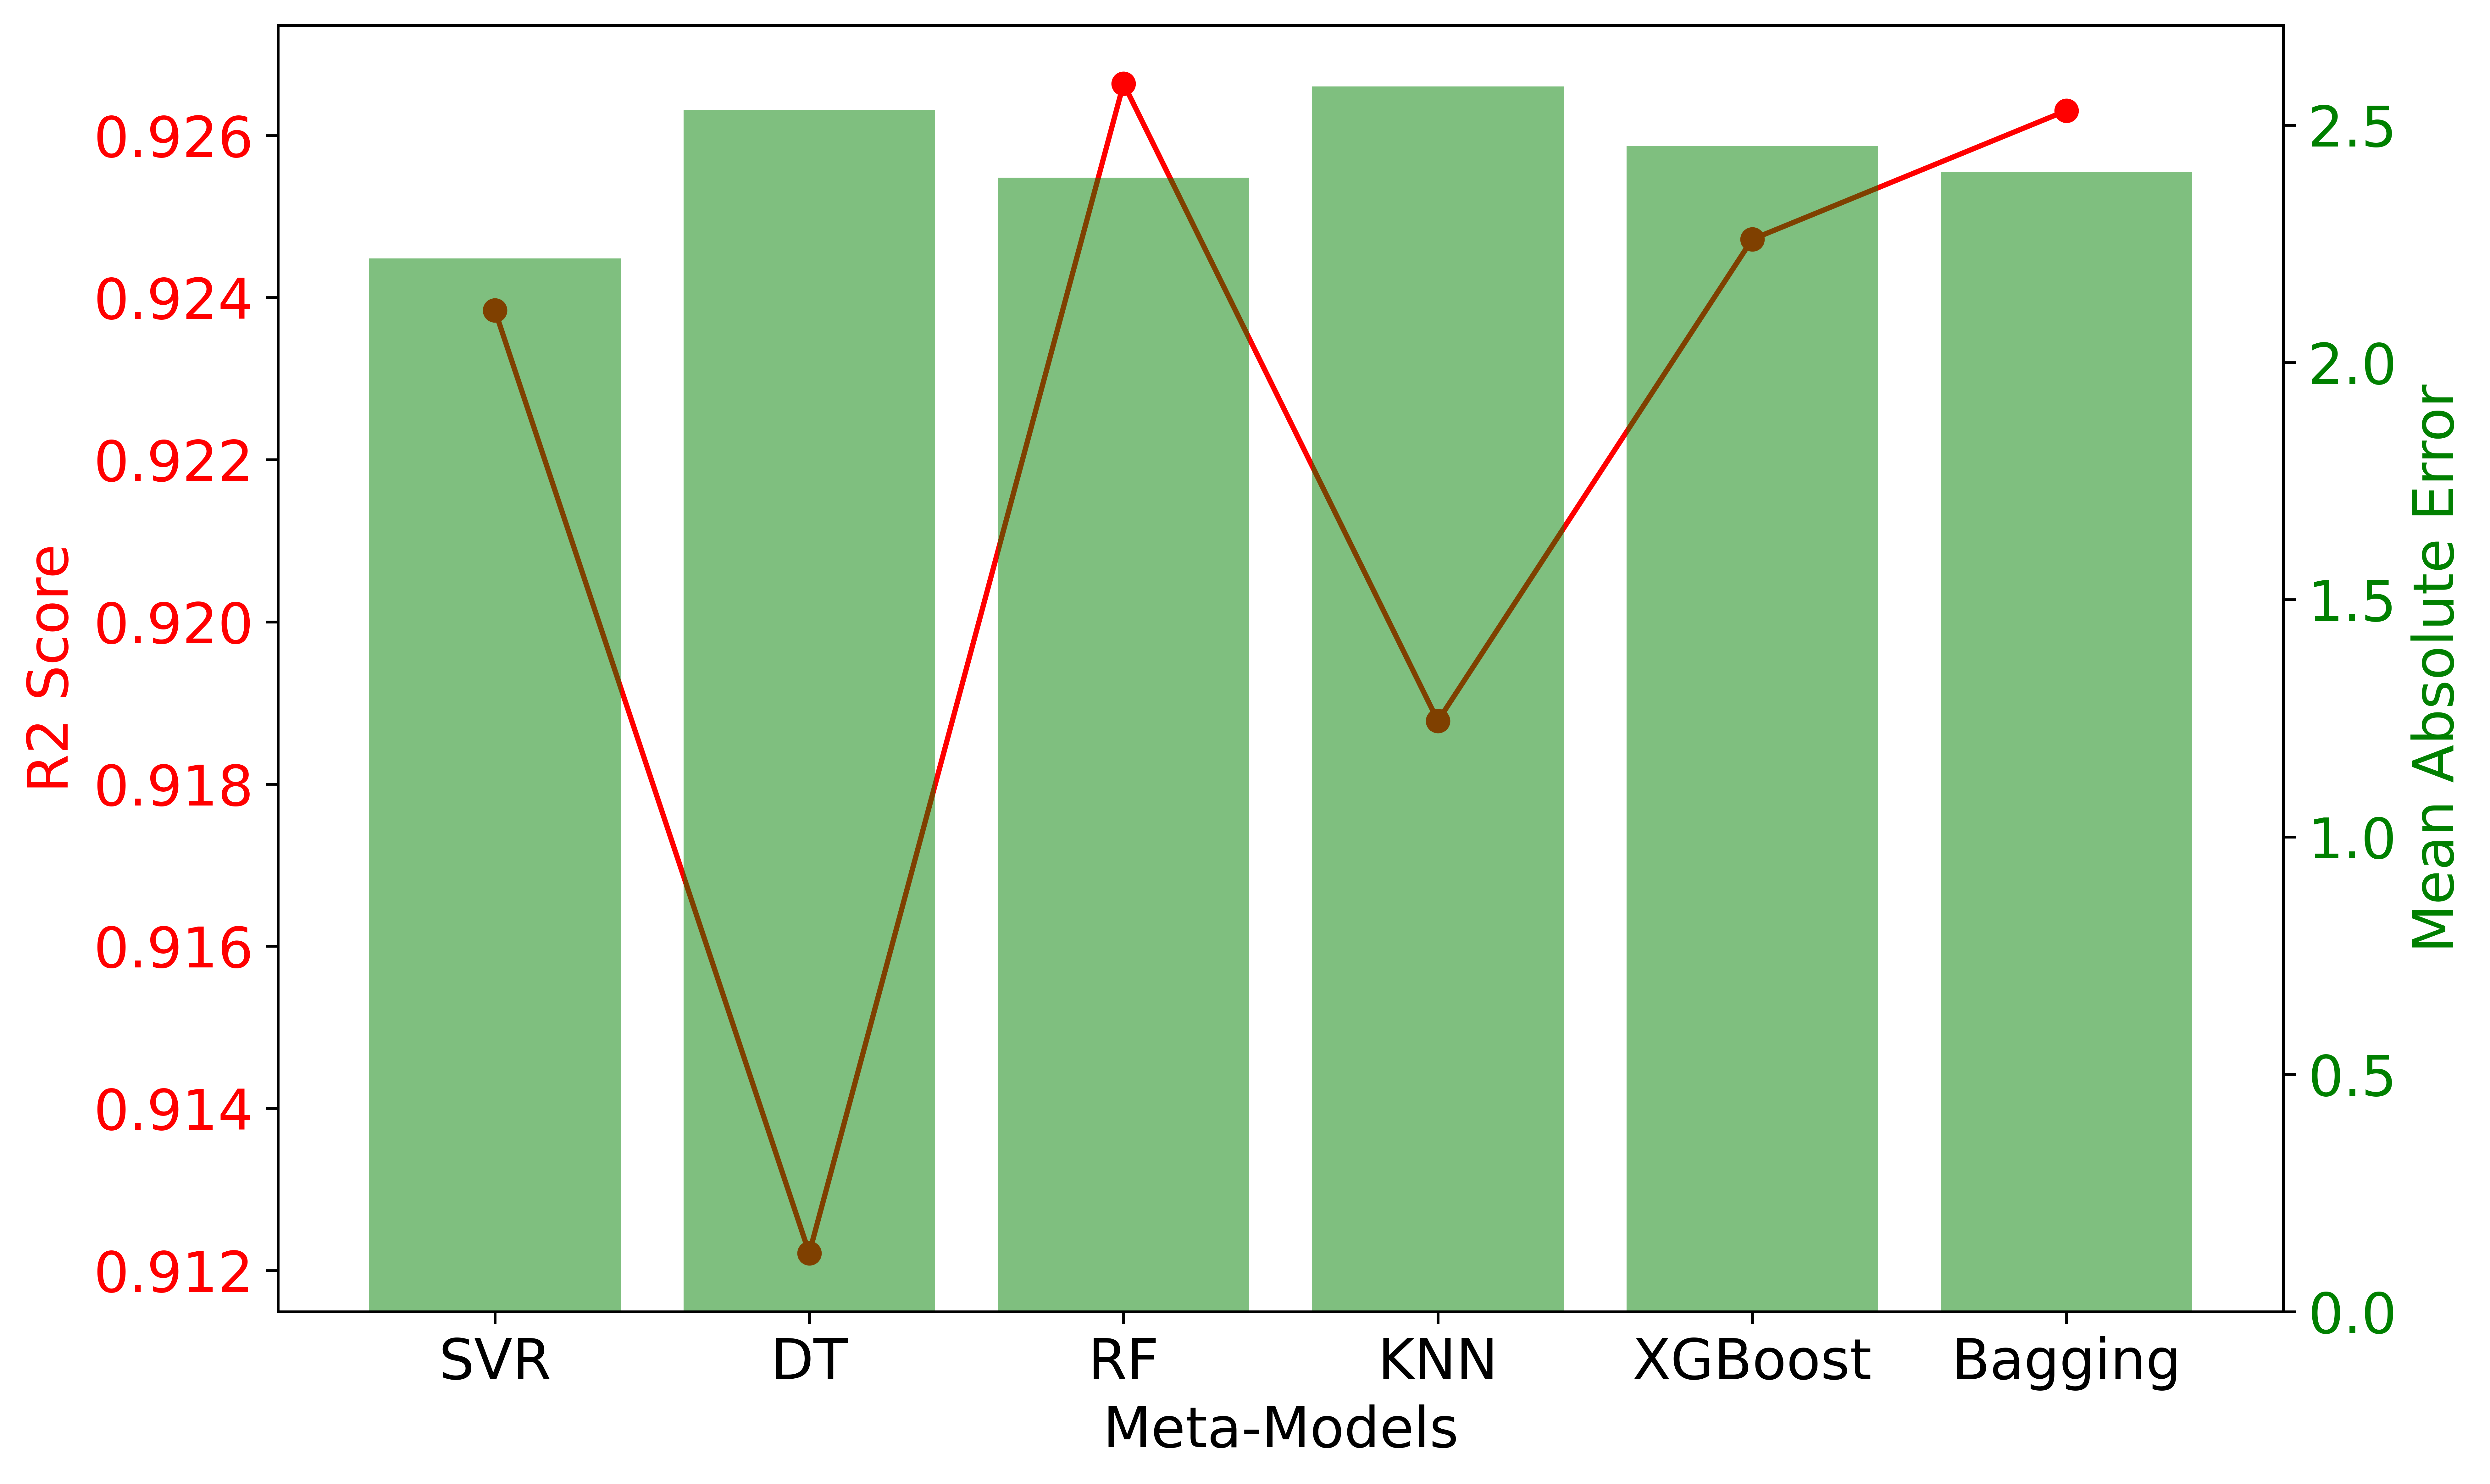

In [5]:
# Plotting R² and MAE for meta-models
meta_model_names = list(meta_models.keys())
r2_scores = []
mae_scores = []

for i, model in enumerate(grid_result.cv_results_['params']):
    r2_score_val = grid_result.cv_results_['mean_test_r2'][i]
    mae_score = -grid_result.cv_results_['mean_test_mae'][i]
    r2_scores.append(r2_score_val)
    mae_scores.append(mae_score)

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=800)

# R2 Line Plot
color = 'red'
ax1.set_xlabel('Meta-Models', fontsize=16)
ax1.set_ylabel('R2 Score', color=color, fontsize=16)
ax1.plot(meta_model_names, r2_scores, color=color, marker='o', label='R2 Score')
ax1.tick_params(axis='y', labelcolor=color, labelsize=16)
ax1.tick_params(axis='x', labelsize=16)

# MAE Bar Plot
ax2 = ax1.twinx()
color = 'green'
ax2.set_ylabel('Mean Absolute Error', color=color, fontsize=16)
ax2.bar(meta_model_names, mae_scores, color=color, alpha=0.5, label='MAE')
ax2.tick_params(axis='y', labelcolor=color, labelsize=16)

fig.tight_layout()
plt.show()